In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join
from pathlib import Path
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [3]:
from mylib import genomes

In [4]:
root_dir = join(Path.home(),"projects/cp_als/second_pair/populations/output/CD")

In [5]:
adf = pd.DataFrame(columns=genomes.keys())
for population_name in genomes:
    genome_ids = genomes[population_name]
    #print(population_name, len(genome_ids))
    df = pd.read_csv(join(root_dir,f"{population_name}/all.csv"))
    df = df[genomes[population_name]+["gene"]]
    variant_mean = df.groupby(['gene']).sum().mean(axis=1)
    adf[population_name] = variant_mean

# Remove disease-associated genes before clustering
adf = adf.drop(index=["NOD2", "IL23R", "ATG16L1", "STAT3"], errors="ignore")

In [6]:
adf.head(10)

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,ESN,FIN,GBR,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
gene,,,,,,,,,,,,,,,,,,,,,
ABCB1,171.154639,161.518519,113.383721,121.924731,122.627451,129.733333,133.212766,180.01,114.019417,117.052083,...,126.333333,181.744898,174.744444,125.428571,135.588235,120.291667,131.182692,111.009804,119.685185,171.068627
ATG4C,110.309278,114.462963,92.395349,89.419355,88.500000,85.876190,97.670213,119.02,83.349515,76.187500,...,91.303030,116.408163,121.055556,95.587302,104.870588,81.885417,105.519231,87.901961,94.453704,119.745098
CARD9,7.567010,7.500000,7.174419,8.505376,6.254902,6.447619,9.351064,7.65,6.970874,7.302083,...,7.343434,7.663265,7.211111,8.761905,10.729412,7.145833,8.375000,7.117647,7.324074,7.274510
CDKAL1,1099.680412,1087.000000,910.476744,901.806452,917.147059,899.695238,934.095745,1107.30,922.514563,904.208333,...,919.959596,1098.744898,1141.855556,919.047619,912.000000,896.177083,944.817308,880.960784,897.870370,1113.607843
DLG5,199.701031,195.944444,189.604651,181.602151,189.392157,184.857143,200.797872,197.05,183.543689,185.333333,...,188.626263,188.346939,200.777778,210.253968,210.494118,190.270833,199.884615,182.529412,157.601852,201.931373
GPR35,46.278351,47.759259,56.290698,58.666667,57.803922,57.657143,50.521277,46.25,51.320388,51.281250,...,59.252525,45.653061,46.311111,49.063492,50.176471,52.677083,49.288462,55.774510,48.787037,46.127451
HLA-DRB1,3.752577,4.259259,3.500000,3.688172,3.656863,3.142857,7.000000,2.44,8.475728,5.375000,...,3.484848,2.959184,3.977778,4.650794,5.047059,1.510417,5.586538,2.460784,4.537037,2.235294
IL10,7.546392,7.407407,6.639535,4.956989,3.941176,4.533333,8.446809,7.31,9.116505,9.739583,...,4.707071,7.540816,6.255556,8.158730,7.235294,7.781250,7.750000,6.196078,8.824074,6.901961
IL10RA,21.876289,21.462963,21.000000,24.182796,22.705882,23.133333,16.138298,23.44,15.990291,16.968750,...,23.818182,20.346939,22.777778,20.063492,21.647059,18.604167,20.067308,18.245098,17.712963,23.352941


In [7]:
tdf = adf.transpose()

In [8]:
tdf

gene,ABCB1,ATG4C,CARD9,CDKAL1,DLG5,GPR35,HLA-DRB1,IL10,IL10RA,IL10RB,...,MST1,NKX2-3,PTPN2,PTPN22,SLC22A4,SLC22A5,TLR4,TNF,TNFSF15,ZMIZ1
ACB,171.154639,110.309278,7.567010,1099.680412,199.701031,46.278351,3.752577,7.546392,21.876289,83.391753,...,4.484536,4.525773,127.494845,48.979381,64.855670,39.319588,30.979381,0.494845,16.360825,366.319588
ASW,161.518519,114.462963,7.500000,1087.000000,195.944444,47.759259,4.259259,7.407407,21.462963,84.629630,...,4.481481,4.314815,126.648148,48.500000,65.018519,36.777778,29.814815,1.037037,14.962963,374.777778
BEB,113.383721,92.395349,7.174419,910.476744,189.604651,56.290698,3.500000,6.639535,21.000000,80.779070,...,3.162791,4.872093,105.825581,47.534884,43.825581,47.709302,24.546512,0.976744,13.872093,338.569767
CDX,121.924731,89.419355,8.505376,901.806452,181.602151,58.666667,3.688172,4.956989,24.182796,61.645161,...,2.419355,4.053763,107.967742,27.731183,70.763441,55.838710,21.064516,0.408602,12.376344,348.623656
CHB,122.627451,88.500000,6.254902,917.147059,189.392157,57.803922,3.656863,3.941176,22.705882,69.137255,...,2.539216,4.147059,112.303922,27.774510,64.000000,49.470588,19.921569,0.500000,12.000000,355.882353
CHS,129.733333,85.876190,6.447619,899.695238,184.857143,57.657143,3.142857,4.533333,23.133333,66.790476,...,2.447619,4.342857,106.819048,28.038095,63.676190,51.619048,20.076190,0.390476,11.085714,346.000000
CLM,133.212766,97.670213,9.351064,934.095745,200.797872,50.521277,7.000000,8.446809,16.138298,74.893617,...,3.436170,4.340426,113.159574,46.085106,59.489362,37.531915,22.585106,0.808511,14.351064,319.159574
ESN,180.010000,119.020000,7.650000,1107.300000,197.050000,46.250000,2.440000,7.310000,23.440000,90.070000,...,4.630000,4.540000,127.530000,48.700000,64.280000,36.350000,33.190000,0.780000,17.770000,372.880000
FIN,114.019417,83.349515,6.970874,922.514563,183.543689,51.320388,8.475728,9.116505,15.990291,78.970874,...,4.271845,3.805825,118.679612,45.737864,54.669903,46.203883,22.320388,0.495146,13.621359,318.524272
GBR,117.052083,76.187500,7.302083,904.208333,185.333333,51.281250,5.375000,9.739583,16.968750,74.635417,...,3.812500,4.500000,116.083333,51.354167,59.979167,43.458333,23.020833,0.729167,13.260417,321.645833


In [9]:
features = tdf.values
labels = list(tdf.index)

# t-SNE 2D scatter plot

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering


PALETTES = [
    ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"],
    ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E", "#E6AB02", "#A6761D"],
    ["#2F5597", "#C00000", "#548235", "#7F6000", "#5F497A", "#1F4E79", "#3F3F3F"],
]

MARKERS = ["o", "s", "^", "D", "X", "P", "v"]


def plot_tsne_poster_population_legend(
    features,
    labels,
    lr=200,
    per=10,
    scaled=True,
    palette_id=0,
    out_dir="plots",
    filename_prefix="tsne_population",
    figsize=(12, 8),
):

    # -------------------------
    # Scaling
    # -------------------------
    if scaled:
        X = StandardScaler().fit_transform(features)
    else:
        X = features

    # -------------------------
    # t-SNE
    # -------------------------
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=per,
        learning_rate=lr
    )
    X_embedded = tsne.fit_transform(X)

    # -------------------------
    # Clustering
    # -------------------------
    n_clusters_map = {3: 5, 5: 4, 7: 3}
    if per not in n_clusters_map:
        raise ValueError(f"per={per} not supported")

    k = n_clusters_map[per]

    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    cluster_ids = agg.fit_predict(X_embedded)

    # -------------------------
    # Styling
    # -------------------------
    palette = PALETTES[palette_id % len(PALETTES)]
    cluster_colors = palette[:k]
    cluster_markers = MARKERS[:k]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # -------------------------
    # Scatter plot
    # -------------------------
    for c in range(k):
        idx = np.where(cluster_ids == c)[0]
        ax.scatter(
            X_embedded[idx, 0],
            X_embedded[idx, 1],
            c=cluster_colors[c],
            marker=cluster_markers[c],
            s=110,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.6,
            zorder=3
        )

    # -------------------------
    # Legend grouped by cluster (NOT alphabetical)
    # -------------------------
    handles = []

    for c in range(k):
        idxs = np.where(cluster_ids == c)[0]

        for i in idxs:  # preserve natural order inside cluster
            handles.append(
                Line2D(
                    [0], [0],
                    marker=cluster_markers[c],
                    linestyle="",
                    markerfacecolor=cluster_colors[c],
                    markeredgecolor="black",
                    markersize=9,
                    label=str(labels[i])
                )
            )

    # Make room for legend
    fig.subplots_adjust(right=0.72)

    ax.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=12,
        handlelength=1.0,
        labelspacing=0.4
    )

    # -------------------------
    # Labels
    # -------------------------
    ax.set_title(
        f"t-SNE (perplexity={per}, lr={lr})",
        fontsize=20,
        fontweight="bold"
    )
    ax.set_xlabel("t-SNE 1", fontsize=16, fontweight="bold")
    ax.set_ylabel("t-SNE 2", fontsize=16, fontweight="bold")
    ax.tick_params(axis="both", labelsize=13)
    ax.grid(True, alpha=0.25)

    # -------------------------
    # Save
    # -------------------------
    # os.makedirs(out_dir, exist_ok=True)
    # filename = f"{filename_prefix}_per{per}_lr{lr}_k{k}_palette{palette_id}.png"
    # path = os.path.join(out_dir, filename)

    # plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    # print(f"Plot saved as: {path}")
    # return path

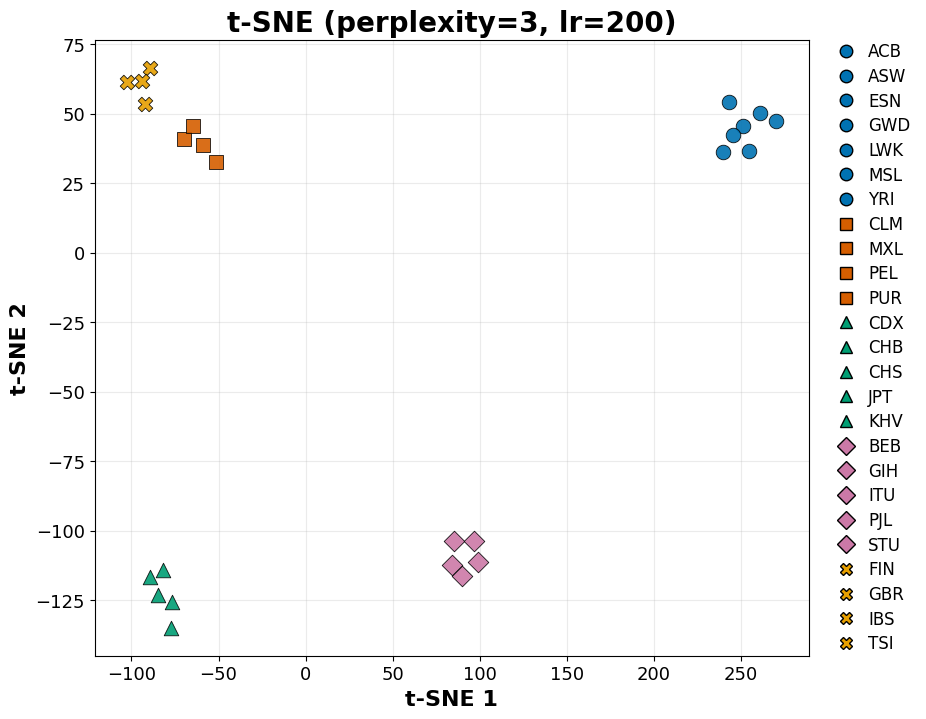

In [11]:
plot_tsne_poster_population_legend(features, labels, per=3, lr=200, palette_id=0, filename_prefix="tsne_agglomerative")